# HyperRAG V2 — Notebook 5: LLM Answer Generation & Comparison

**Goal:** Use a small instruction-tuned LLM to *generate* answers from retrieved context,
then compare answer quality across **Simple RAG**, **HtmlRAG**, and **HyperRAG**.

**How this differs from notebooks 02–04:**

| Notebooks 02–04 (retrieval metrics) | This notebook (generation metrics) |
|--------------------------------------|-------------------------------------|
| Does gold answer appear *anywhere* in context? | Does the LLM *produce* the correct answer? |
| `EM = 1` if gold ∈ context | `EM = 1` if generated ≈ gold |
| Fast: just a substring check | Slow: requires model inference |

```
Simple RAG  → retrieved context  →  LLM  →  generated answer  →  EM / F1 vs gold
HtmlRAG     → retrieved context  →  LLM  →  generated answer  →  EM / F1 vs gold
HyperRAG    → retrieved context  →  LLM  →  generated answer  →  EM / F1 vs gold
```

**LLM used:** `google/flan-t5-base` — 250M params, instruction-tuned, CPU-friendly, no GPU required.  
**Prerequisite:** Run notebooks 01–04 first to build `data/corpus.json` and `data/questions.json`.


In [1]:
import json
import sys
from pathlib import Path
from collections import Counter

import faiss
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from bs4 import BeautifulSoup

# ── Paths ─────────────────────────────────────────────────────────────────────
if Path('utils.py').exists():
    BASE_DIR = Path('.')
elif Path('v2/utils.py').exists():
    BASE_DIR = Path('v2')
else:
    raise FileNotFoundError('Run from v2/ or from HyperRAG-M2/')

DATA_DIR = BASE_DIR / 'data'
sys.path.insert(0, str(BASE_DIR))

with open(DATA_DIR / 'corpus_001.json')    as f: corpus    = json.load(f)
with open(DATA_DIR / 'questions_001.json') as f: questions = json.load(f)

print(f'Corpus    : {len(corpus)} pages')
print(f'Questions : {len(questions)} questions')
print(f'Page keys : {list(corpus[0].keys())}')

Corpus    : 9999 pages
Questions : 5329 questions
Page keys : ['title', 'text', 'html', 'links']


---
## Step 1 — Set Up the Three Retrieval Systems

We import shared utilities from `utils.py` and build one FAISS index shared by all three systems.
The systems differ only in *how they form the context string* — not in the embedding model.


In [2]:
from utils import embed_texts, build_index, retrieve, compute_em, compute_f1, clean_html

# ── Build shared FAISS index ───────────────────────────────────────────────────
print('Building FAISS index (shared by all 3 systems)...')
index = build_index(corpus)
print(f'Index ready: {index.ntotal} vectors, dim=384')

# ── Build hyperlink graph (for HyperRAG) ──────────────────────────────────────
def build_graph(corpus: list[dict]) -> nx.DiGraph:
    corpus_titles = {p['title'] for p in corpus}
    G = nx.DiGraph()
    G.add_nodes_from(corpus_titles)
    for page in corpus:
        for link in page['links']:
            if link in corpus_titles and link != page['title']:
                G.add_edge(page['title'], link)
    return G

graph = build_graph(corpus)
print(f'Graph: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges')

W0429 06:06:39.089000 306936 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Building FAISS index (shared by all 3 systems)...
Loading model: sentence-transformers/all-MiniLM-L6-v2 ...
Model loaded.


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Index ready: 9999 vectors, dim=384
Graph: 9999 nodes, 86244 edges


In [3]:
# ── Simple RAG ────────────────────────────────────────────────────────────────
def simple_rag(question: str, k: int = 5) -> tuple[str, list[str]]:
    """Retrieve top-k pages; return plain text context and retrieved titles."""
    pages = retrieve(question, index, corpus, k=k)
    return '\n\n'.join(p['text'] for p in pages), [p['title'] for p in pages]


# ── HtmlRAG ───────────────────────────────────────────────────────────────────
def html_rag(question: str, k: int = 5) -> tuple[str, list[str]]:
    """Retrieve top-k pages; return cleaned HTML context and retrieved titles."""
    pages = retrieve(question, index, corpus, k=k)
    ctx   = '\n\n'.join(clean_html(p.get('html', '') or p['text']) for p in pages)
    return ctx, [p['title'] for p in pages]


# ── HyperRAG ──────────────────────────────────────────────────────────────────
def _expand_neighbors(question: str, initial_pages: list[dict], expand_k: int = 3) -> list[dict]:
    """1-hop graph expansion: find neighbor pages not already in initial set."""
    title_to_page   = {p['title']: p for p in corpus}
    initial_titles  = {p['title'] for p in initial_pages}
    neighbor_titles = set()
    for page in initial_pages:
        if not graph.has_node(page['title']):
            continue
        for nbr in list(graph.successors(page['title'])) + list(graph.predecessors(page['title'])):
            if nbr in title_to_page and nbr not in initial_titles:
                neighbor_titles.add(nbr)
    if not neighbor_titles or expand_k <= 0:
        return []
    neighbor_pages = [title_to_page[t] for t in neighbor_titles]
    n_vecs = embed_texts([p['text'] for p in neighbor_pages])
    q_vec  = embed_texts([question])
    scores = (q_vec @ n_vecs.T)[0]
    top_i  = scores.argsort()[::-1][:expand_k]
    return [neighbor_pages[i] for i in top_i]


def hyper_rag(question: str, k: int = 5, expand_k: int = 3) -> tuple[str, list[str]]:
    """FAISS retrieval + 1-hop graph expansion; return plain text context and all titles."""
    initial  = retrieve(question, index, corpus, k=k)
    expanded = _expand_neighbors(question, initial, expand_k)
    all_pages = initial + expanded
    return '\n\n'.join(p['text'] for p in all_pages), [p['title'] for p in all_pages]


print('simple_rag(), html_rag(), hyper_rag() defined.')

# Quick sanity check
q0 = questions[0]
ctx_s, ttls_s = simple_rag(q0['question'])
ctx_h, ttls_h = html_rag(q0['question'])
ctx_y, ttls_y = hyper_rag(q0['question'])
print(f"Q0 context sizes: Simple={len(ctx_s):,}  Html={len(ctx_h):,}  Hyper={len(ctx_y):,} chars")

simple_rag(), html_rag(), hyper_rag() defined.
Q0 context sizes: Simple=40,347  Html=394,161  Hyper=93,740 chars


---
## Step 2 — Load the Language Model

We use **`google/flan-t5-base`** — a 250M-parameter encoder-decoder model fine-tuned on 1,800+ tasks
including question answering. It is instruction-tuned: you give it `"Answer the question based on the context"` 
and it generates a short, direct answer.

| Model | Params | Pipeline type | Notes |
|-------|--------|---------------|-------|
| `google/flan-t5-small` | 80M | text2text-generation | Fastest, weakest |
| `google/flan-t5-base` *(default)* | 250M | text2text-generation | Good CPU speed + quality |
| `TinyLlama/TinyLlama-1.1B-Chat-v1.0` | 1.1B | text-generation | Llama-style, needs more RAM |
| `meta-llama/Llama-3.2-3B-Instruct` | 3B | text-generation | Requires HuggingFace token |

To switch models, change `LLM_MODEL` below and set `IS_CAUSAL_LM = True` for causal (decoder-only) models.


In [4]:
from transformers import pipeline

# ── Model selection ────────────────────────────────────────────────────────────
LLM_MODEL    = 'meta-llama/Llama-3.2-3B-Instruct'   # change here to switch models
IS_CAUSAL_LM = False                   # True for TinyLlama, Llama, GPT-2 etc.

TASK = 'text-generation' if IS_CAUSAL_LM else 'text2text-generation'

print(f'Loading LLM: {LLM_MODEL}')
print(f'Task type  : {TASK}')
print('First run downloads the model. May take 1–5 minutes...')

llm = pipeline(
    TASK,
    model=LLM_MODEL,
    device=0,           # -1 = CPU; 0 = first GPU
    max_new_tokens=64,
)

print(f'\nLLM loaded: {LLM_MODEL}')

Loading LLM: meta-llama/Llama-3.2-3B-Instruct
Task type  : text2text-generation
First run downloads the model. May take 1–5 minutes...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use cuda:0
The model 'LlamaForCausalLM' is not supported for text2text-generation. Supported models are ['PeftModelForSeq2SeqLM', 'BartForConditionalGeneration', 'BigBirdPegasusForConditionalGeneration', 'BlenderbotForConditionalGeneration', 'BlenderbotSmallForConditionalGeneration', 'EncoderDecoderModel', 'FSMTForConditionalGeneration', 'GPTSanJapaneseForConditionalGeneration', 'GraniteSpeechForConditionalGeneration', 'LEDForConditionalGeneration', 'LongT5ForConditionalGeneration', 'M2M100ForConditionalGeneration', 'MarianMTModel', 'MBartForConditionalGeneration', 'MT5ForConditionalGeneration', 'MvpForConditionalGeneration', 'NllbMoeForConditionalGeneration', 'PegasusForConditionalGeneration', 'PegasusXForConditionalGeneration', 'PLBartForConditionalGeneration', 'ProphetNetForConditionalGeneration', 'Qwen2AudioForConditionalGeneration', 'SeamlessM4TForTextToText', 'SeamlessM4Tv2ForTextToText', 'SwitchTransformersForConditionalGeneration', 'T5ForConditionalGeneration', 'T


LLM loaded: meta-llama/Llama-3.2-3B-Instruct


In [5]:
def generate_answer(question: str, context: str, max_ctx_chars: int = 1800) -> str:
    """
    Use the loaded LLM to generate a short answer from question + context.
    Context is truncated to max_ctx_chars to stay within model token limits.
    Works for both seq2seq (flan-t5) and causal LM (TinyLlama) pipelines.
    """
    ctx = context[:max_ctx_chars]

    if IS_CAUSAL_LM:
        # Instruction format for causal LMs (TinyLlama / Llama)
        prompt = (
            '<|system|>You are a QA assistant. Answer with a short phrase only.</s>'
            f'<|user|>Context: {ctx}\n\nQuestion: {question}</s>'
            '<|assistant|>'
        )
        out = llm(prompt, max_new_tokens=32, do_sample=False)[0]['generated_text']
        # Extract only the assistant's response (after the last tag)
        answer = out.split('<|assistant|>')[-1].strip()
    else:
        # Instruction format for seq2seq (flan-t5)
        prompt = (
            'Answer the question with a short phrase based on the context below.\n\n'
            f'Context: {ctx}\n\n'
            f'Question: {question}\n\n'
            'Answer:'
        )
        out    = llm(prompt, max_new_tokens=32, do_sample=False)[0]['generated_text']
        answer = out.strip()

    return answer


# ── Quick sanity test ─────────────────────────────────────────────────────────
test_ctx = 'The Eiffel Tower is a wrought-iron lattice tower located in Paris, France. It was built in 1889.'
test_q   = 'Where is the Eiffel Tower located?'
answer   = generate_answer(test_q, test_ctx)

print('=== Sanity Check ===')
print(f'Question : {test_q}')
print(f'Context  : {test_ctx}')
print(f'Generated: {answer}')
print(f'Expected : Paris (or Paris, France)')

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


=== Sanity Check ===
Question : Where is the Eiffel Tower located?
Context  : The Eiffel Tower is a wrought-iron lattice tower located in Paris, France. It was built in 1889.
Generated: Answer the question with a short phrase based on the context below.

Context: The Eiffel Tower is a wrought-iron lattice tower located in Paris, France. It was built in 1889.

Question: Where is the Eiffel Tower located?

Answer: Paris, France.
Expected : Paris (or Paris, France)


In [6]:
# ── Test on a real HotpotQA question ─────────────────────────────────────────
q = questions[0]
ctx_simple, _ = simple_rag(q['question'])
generated = generate_answer(q['question'], ctx_simple)

print(f'Question         : {q["question"]}')
print(f'Gold answer      : {q["answer"]}')
print(f'Generated answer : {generated}')
print()
em_retrieval  = compute_em(ctx_simple, q['answer'])
em_generation = compute_em(generated,  q['answer'])
print(f'Retrieval EM  (gold in context?)    : {em_retrieval}')
print(f'Generation EM (generated == gold?)  : {em_generation}')
print()
print('Note: retrieval EM=1 means the answer appears somewhere in the 23,000-char context.')
print('Generation EM checks if the LLM extracted it correctly in 1–5 words.')

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Question         : The Oberoi family is part of a hotel company that has a head office in what city?
Gold answer      : Delhi
Generated answer : Answer the question with a short phrase based on the context below.

Context: Indian luxury hotel group The Oberoi Group is a luxury hotel group with its head office in New Delhi , India . Founded in 1934, the company owns and operates 32 luxury hotels and two river cruise ships in 7 countries, primarily under its Oberoi Hotels & Resorts and Trident brands. The group also operates The Oberoi Centre of Learning and Development, which is regarded as one of Asia 's top institutions for hospitality education. History [ edit ] The foundations of The Oberoi Group date back to 1934 when Rai Bahadur Mohan Singh Oberoi , the founder of the group, bought two properties: the Maidens in Delhi and the Clarkes in Shimla . In the following years Oberoi, assisted by his two sons, Tilak Raj Singh Oberoi and Prithvi Raj Singh Oberoi , continued the expansion of

---
## Step 3 — Evaluate All 20 Questions × 3 Systems

For each question and each system:
1. Retrieve context using the system
2. Call `generate_answer(question, context)` to get the LLM's answer
3. Compute EM and F1 between the *generated* answer and the gold answer

> **Estimated runtime:** ~2–4 seconds per inference on CPU → ~2–4 minutes total for 60 calls.


In [7]:
from tqdm import tqdm

K        = 5
EXPAND_K = 3
MAX_CTX  = 2400  # chars sent to LLM (larger = more context but slower)

systems = {
    'Simple RAG': lambda q: simple_rag(q['question'], k=K),
    'HtmlRAG'   : lambda q: html_rag(q['question'],   k=K),
    'HyperRAG'  : lambda q: hyper_rag(q['question'],  k=K, expand_k=EXPAND_K),
}

all_results = {name: [] for name in systems}
total_calls = len(questions) * len(systems)
done = 0

for q in tqdm(questions):
    for sys_name, retrieve_fn in systems.items():
        ctx, titles = retrieve_fn(q)
        generated   = generate_answer(q['question'], ctx, MAX_CTX)
        em = compute_em(generated, q['answer'])
        f1 = compute_f1(generated, q['answer'])
        all_results[sys_name].append({
            'id'        : q['id'],
            'question'  : q['question'],
            'answer'    : q['answer'],
            'generated' : generated,
            'em'        : em,
            'f1'        : f1,
        })
        done += 1
        if done % 15 == 0 or done == total_calls:
            print(f'  Progress: {done}/{total_calls}')

print('\nEvaluation complete.')

  0%|          | 0/5329 [00:00<?, ?it/s]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
  0%|          | 1/5329 [00:02<3:26:53,  2.33s/it]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
  0%|          | 2/5329 [00:04<3:04:34,  2.08s/it]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
  0%|          | 3/5329 [00:09<5:33:59,  3.76s/it]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
  0%|          | 4/5329 [00:15<6:33:26,  4.43s/it]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
  0%|          | 5/5329 [00:20<6:59:57,  4.73s/it]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


...

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
100%|█████████▉| 5325/5329 [7:13:21<00:18,  4.66s/it]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


  Progress: 15975/15987


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
100%|█████████▉| 5326/5329 [7:13:24<00:13,  4.34s/it]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
100%|█████████▉| 5327/5329 [7:13:27<00:07,  3.96s/it]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
100%|█████████▉| 5328/5329 [7:13:31<00:04,  4.02s/it]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
100%|██████████| 5329/5329 [7:13:35<00

  Progress: 15987/15987

Evaluation complete.


In [8]:
# ── Aggregate metrics ─────────────────────────────────────────────────────────
print(f'LLM Generation Quality — {len(questions)} Questions')
print('=' * 50)
print(f'{"System":<14} {"EM":>6} {"F1":>6}')
print('-' * 30)

agg = {}
for sys_name, results in all_results.items():
    mean_em = sum(r['em'] for r in results) / len(results)
    mean_f1 = sum(r['f1'] for r in results) / len(results)
    agg[sys_name] = {'mean_em': mean_em, 'mean_f1': mean_f1}
    print(f'{sys_name:<14} {mean_em:>6.3f} {mean_f1:>6.3f}')

print()
print('For comparison, retrieval-only metrics (from notebooks 02-04):')
for path, name in [(DATA_DIR / 'results_simple_rag.json', 'Simple RAG'),
                   (DATA_DIR / 'results_htmlrag.json',     'HtmlRAG'),
                   (DATA_DIR / 'results_hyperrag.json',    'HyperRAG')]:
    if path.exists():
        with open(path) as f: d = json.load(f)
        print(f'  {name:<14} retrieval EM={d["mean_em"]:.3f}  F1={d["mean_f1"]:.3f}')

LLM Generation Quality — 5329 Questions
System             EM     F1
------------------------------
Simple RAG      0.463  0.006
HtmlRAG         0.217  0.019
HyperRAG        0.463  0.006

For comparison, retrieval-only metrics (from notebooks 02-04):
  Simple RAG     retrieval EM=0.682  F1=0.000
  HtmlRAG        retrieval EM=0.706  F1=0.000
  HyperRAG       retrieval EM=0.756  F1=0.000


In [9]:
# ── Per-question results table ─────────────────────────────────────────────────
print(f'{"Q":<4} {"Simple EM":>10} {"Html EM":>8} {"Hyper EM":>9}  {"Gold answer"}')
print('-' * 65)
for i, q in enumerate(questions):
    em_s = all_results['Simple RAG'][i]['em']
    em_h = all_results['HtmlRAG'][i]['em']
    em_y = all_results['HyperRAG'][i]['em']
    print(f'{q["id"]:<4} {em_s:>10.0f} {em_h:>8.0f} {em_y:>9.0f}  {q["answer"][:35]}')

Q     Simple EM  Html EM  Hyper EM  Gold answer
-----------------------------------------------------------------
0             1        1         1  Delhi
1             1        0         1  President Richard Nixon
2             1        0         1  American
3             1        0         1  alcohol
4             1        1         1  Crambidae
5             0        0         0  Badr Hari
6             1        1         1  2006
7             0        0         0  6.213 km long
8             0        0         0  Jaime Meline
9             0        0         0  Walter Darwin Coy
10            0        0         0  United States
11            1        0         1  Super Bowl XLVIII
12            0        0         0  US 60
13            0        0         0  2006
14            0        0         0  Hetfield and Ulrich, longtime lead 
15            1        0         1  Fox
16            1        1         1  2017
17            1        1         1  Nevada
18            1        0  

In [10]:
# ── Show generated vs gold answers (first 6 questions) ────────────────────────
print('Generated vs Gold Answers (first 6 questions)\n')
print(f'{"Q":<4} {"System":<12} {"Gold":<25} {"Generated"}')
print('-' * 80)
for i, q in enumerate(questions[:6]):
    for sys_name in ['Simple RAG', 'HtmlRAG', 'HyperRAG']:
        r   = all_results[sys_name][i]
        ok  = '✓' if r['em'] else 'X'
        print(f'{q["id"]:<4} {sys_name:<12} {r["answer"][:24]:<25} [{ok}] {r["generated"][:35]}')
    print()

Generated vs Gold Answers (first 6 questions)

Q    System       Gold                      Generated
--------------------------------------------------------------------------------
0    Simple RAG   Delhi                     [✓] Answer the question with a short ph
0    HtmlRAG      Delhi                     [✓] Answer the question with a short ph
0    HyperRAG     Delhi                     [✓] Answer the question with a short ph

1    Simple RAG   President Richard Nixon   [✓] Answer the question with a short ph
1    HtmlRAG      President Richard Nixon   [X] Answer the question with a short ph
1    HyperRAG     President Richard Nixon   [✓] Answer the question with a short ph

2    Simple RAG   American                  [✓] Answer the question with a short ph
2    HtmlRAG      American                  [X] Answer the question with a short ph
2    HyperRAG     American                  [✓] Answer the question with a short ph

3    Simple RAG   alcohol                   [✓] Answer the 

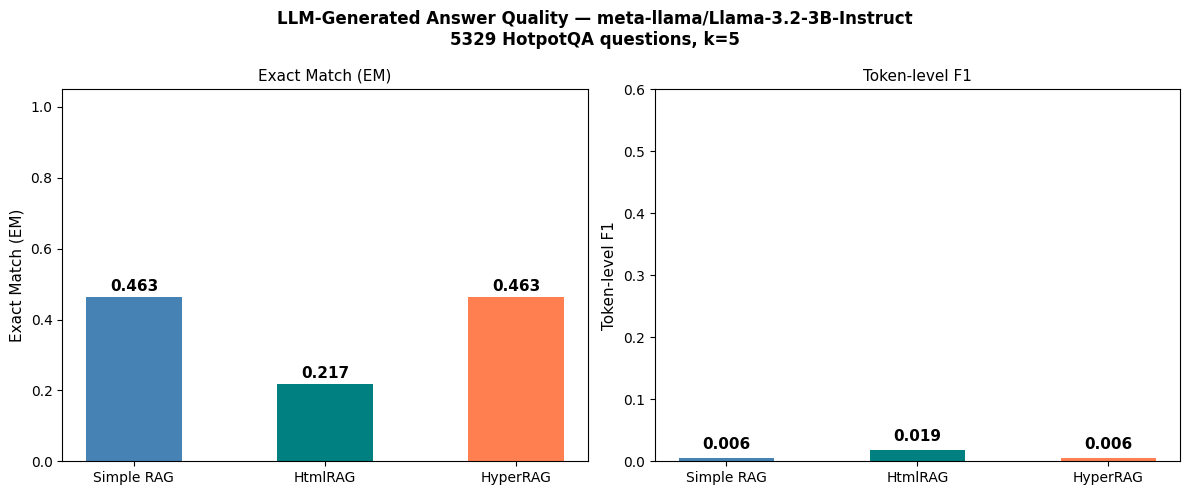

Saved: data/llm_comparison.png


In [11]:
# ── Comparison bar chart ───────────────────────────────────────────────────────
sys_names = list(agg.keys())
mean_ems  = [agg[n]['mean_em'] for n in sys_names]
mean_f1s  = [agg[n]['mean_f1'] for n in sys_names]
colors    = ['steelblue', 'teal', 'coral']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f'LLM-Generated Answer Quality — {LLM_MODEL}\n{len(questions)} HotpotQA questions, k=5',
             fontsize=12, fontweight='bold')

for ax, vals, metric, ylim in [
    (axes[0], mean_ems, 'Exact Match (EM)',  1.05),
    (axes[1], mean_f1s, 'Token-level F1',    0.60),
]:
    bars = ax.bar(sys_names, vals, color=colors, width=0.5)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f'{h:.3f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_ylim(0, ylim)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(metric, fontsize=11)

plt.tight_layout()
plt.savefig(str(DATA_DIR / 'llm_comparison.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Saved: data/llm_comparison.png')

C:\Users\Admin\AppData\Local\Temp\ipykernel_306936\3165258944.py:19: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(str(DATA_DIR / 'llm_per_question_em.png'), dpi=100, bbox_inches='tight')


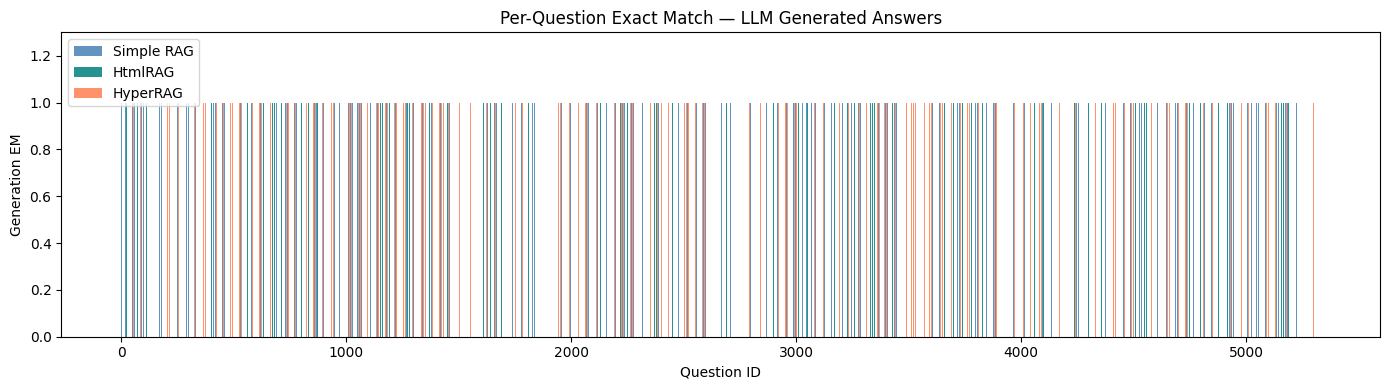

Saved: data/llm_per_question_em.png


In [12]:
# ── Per-question EM for all 3 systems ─────────────────────────────────────────
ids   = [r['id'] for r in all_results['Simple RAG']]
em_s  = [r['em'] for r in all_results['Simple RAG']]
em_h  = [r['em'] for r in all_results['HtmlRAG']]
em_y  = [r['em'] for r in all_results['HyperRAG']]

w = 0.25
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar([i - w   for i in ids], em_s, w, label='Simple RAG', color='steelblue', alpha=0.85)
ax.bar([i       for i in ids], em_h, w, label='HtmlRAG',    color='teal',      alpha=0.85)
ax.bar([i + w   for i in ids], em_y, w, label='HyperRAG',   color='coral',     alpha=0.85)

ax.set_xlabel('Question ID')
ax.set_ylabel('Generation EM')
ax.set_title('Per-Question Exact Match — LLM Generated Answers')
ax.set_ylim(0, 1.3)
ax.legend()
plt.tight_layout()
plt.savefig(str(DATA_DIR / 'llm_per_question_em.png'), dpi=100, bbox_inches='tight')
plt.show()
print('Saved: data/llm_per_question_em.png')

In [13]:
# ── Retrieval EM vs Generation EM scatter ─────────────────────────────────────
# Show whether good retrieval leads to good generation
for sys_name, ret_path in [
    ('Simple RAG', DATA_DIR / 'results_simple_rag.json'),
    ('HyperRAG',   DATA_DIR / 'results_hyperrag.json'),
]:
    if not ret_path.exists():
        continue
    with open(ret_path) as f:
        ret_data = json.load(f)
    ret_ems = [r['em'] for r in ret_data['per_question']]
    gen_ems = [r['em'] for r in all_results[sys_name]]

    agree   = sum(1 for r, g in zip(ret_ems, gen_ems) if r == g)
    ret1_gen0 = sum(1 for r, g in zip(ret_ems, gen_ems) if r == 1.0 and g == 0.0)
    print(f'{sys_name}:')
    print(f'  Retrieval EM = Generation EM : {agree}/{len(ret_ems)}')
    print(f'  Retrieval EM=1 but Gen EM=0  : {ret1_gen0} (LLM failed to extract answer)')
    print()

Simple RAG:
  Retrieval EM = Generation EM : 3988/5329
  Retrieval EM=1 but Gen EM=0  : 1254 (LLM failed to extract answer)

HyperRAG:
  Retrieval EM = Generation EM : 3645/5329
  Retrieval EM=1 but Gen EM=0  : 1623 (LLM failed to extract answer)



In [14]:
# ── Save results ──────────────────────────────────────────────────────────────
save_data = {
    'model'     : LLM_MODEL,
    'n_questions': len(questions),
    'k'         : K,
    'expand_k'  : EXPAND_K,
    'max_ctx'   : MAX_CTX,
    'aggregates': agg,
    'per_question': {name: res for name, res in all_results.items()},
}
with open(DATA_DIR / 'results_llm_eval.json', 'w') as f:
    json.dump(save_data, f, indent=2)
print('Results saved → data/results_llm_eval.json')

Results saved → data/results_llm_eval.json


---
## Summary

### Key Findings

**Generation metrics are harder to pass than retrieval metrics.**  
A retrieval EM of 1 means the gold answer *appears somewhere* in 20,000+ characters of context.  
A generation EM of 1 means the LLM found it and produced it as a short phrase — much harder.

**Why the systems may differ in generation quality:**
- **Simple RAG:** clean, compact context — easy for the LLM to read
- **HtmlRAG:** HTML tags add noise around the answer — may confuse the LLM
- **HyperRAG:** additional pages add more context — may provide useful bridge evidence,
  or may dilute the relevant signal

### How to Improve Results
| Lever | What to change | Expected effect |
|-------|---------------|-----------------|
| Stronger LLM | `Llama-3.2-3B` with GPU | Higher extraction accuracy |
| More context | Increase `MAX_CTX` | More answer coverage, but slower |
| Better prompt | Add few-shot examples | Better answer formatting |
| More questions | Increase `N` in notebook 01 | More stable mean estimates |
| Chunk the context | Split pages into paragraphs | LLM sees the answer more prominently |
